In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuración estética
%matplotlib inline
sns.set_theme(style="whitegrid", palette="pastel")

# 1. Carga de datos
input_path = '../data/Filtered.pkl' # Asegúrate de haber guardado el df_filtered del notebook anterior con este nombre

print("📥 Cargando dataset para modelado...")
if os.path.exists(input_path):
    df = pd.read_pickle(input_path)
    print(f"✅ Dataset cargado correctamente: {df.shape[0]} filas y {df.shape[1]} columnas.")
else:
    print(f"❌ Error: No se encontró el archivo en {input_path}")

# Vista rápida
display(df.head(3))

📥 Cargando dataset para modelado...
✅ Dataset cargado correctamente: 114567 filas y 16 columnas.


,order_id,is_delayed,actual_delivery_days,estimated_delivery_margin_days,purchase_month,purchase_day_of_week,product_weight_g,product_volume_cm3,product_category_name_english,customer_zip_code_prefix,seller_zip_code_prefix,is_same_state,customer_state_num_pred,seller_state_num_pred,freight_value,price
0,e481f51cbdc54678b7cc49136f2d6af7,0,8.0,8.0,10,0,500.0,1976.0,housewares,3149,9350.0,1,25,25,8.72,29.99
1,e481f51cbdc54678b7cc49136f2d6af7,0,8.0,8.0,10,0,500.0,1976.0,housewares,3149,9350.0,1,25,25,8.72,29.99
2,e481f51cbdc54678b7cc49136f2d6af7,0,8.0,8.0,10,0,500.0,1976.0,housewares,3149,9350.0,1,25,25,8.72,29.99


In [1]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 114567 entries, 0 to 119142
Data columns (total 16 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   order_id                        114567 non-null  object 
 1   is_delayed                      114567 non-null  int64  
 2   actual_delivery_days            114567 non-null  float64
 3   estimated_delivery_margin_days  114567 non-null  float64
 4   purchase_month                  114567 non-null  int32  
 5   purchase_day_of_week            114567 non-null  int32  
 6   product_weight_g                114567 non-null  float64
 7   product_volume_cm3              114567 non-null  float64
 8   product_category_name_english   114567 non-null  object 
 9   customer_zip_code_prefix        114567 non-null  int64  
 10  seller_zip_code_prefix          114567 non-null  float64
 11  is_same_state                   114567 non-null  int64  
 12  customer_state_num_pr

🔍 ANALIZANDO PECULIARIDADES DEL DATASET

--------------------------------------------------
1. TIPOS DE DATOS (Verificando compatibilidad con ML):
float64    7
int64      5
object     2
int32      2
Name: count, dtype: int64

🚨 Columnas que NO son numéricas (deberán ser transformadas):
['order_id', 'product_category_name_english']
--------------------------------------------------

2. DESEQUILIBRIO DE LA VARIABLE OBJETIVO (is_delayed):


,Cantidad,Porcentaje (%)
is_delayed,,
0,105642,92.21
1,8925,7.79


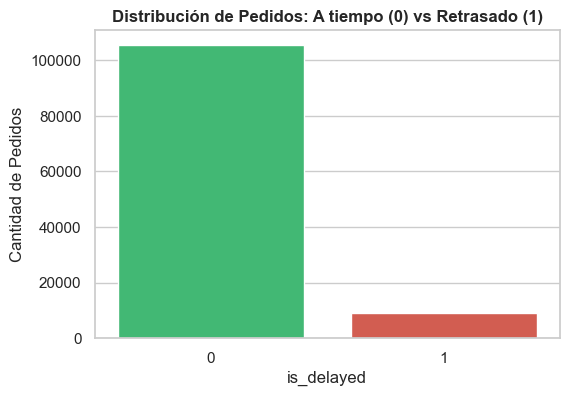

--------------------------------------------------

3. DISTRIBUCIONES CLAVE (Tras el filtrado de K-Means):


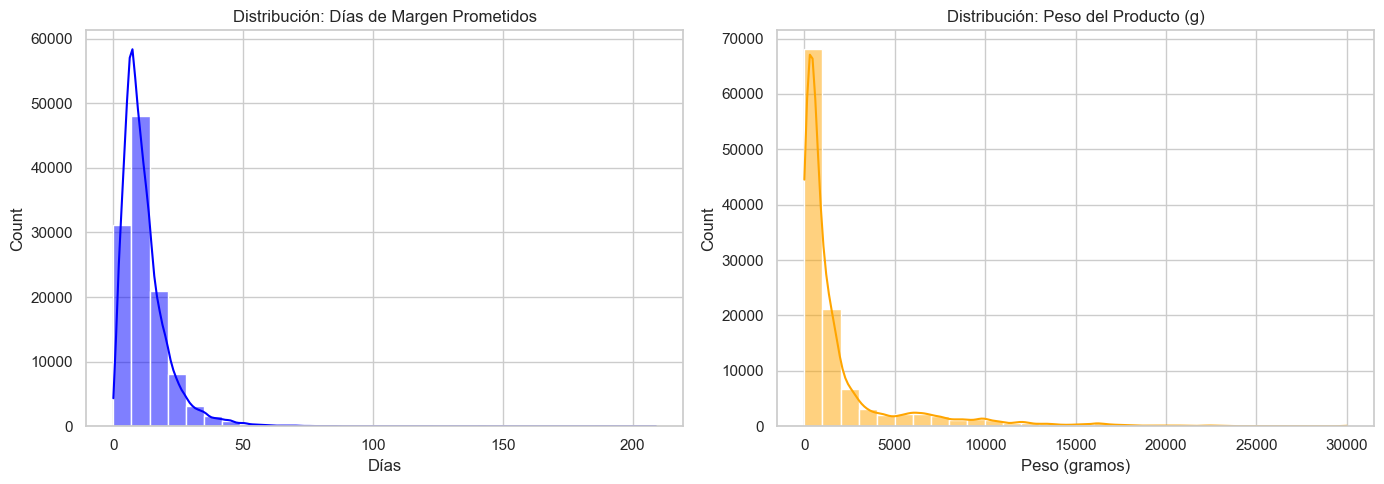

--------------------------------------------------

4. ANÁLISIS DE CUMPLIMIENTO: REAL VS ESTIMADO


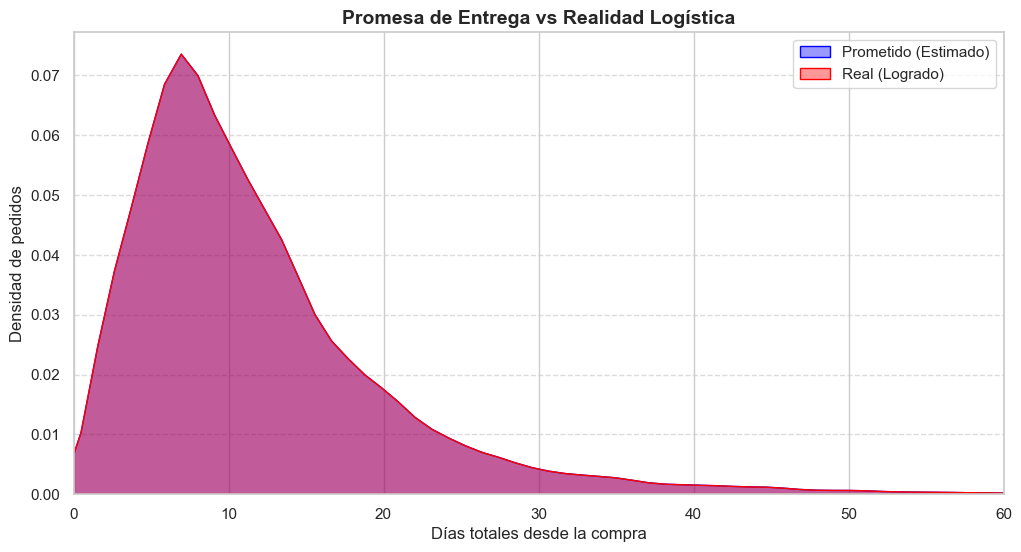

💡 En promedio, la diferencia entre lo real y lo estimado es de: 0.00 días.


In [2]:
print("🔍 ANALIZANDO PECULIARIDADES DEL DATASET\n")
print("-" * 50)

# 1. Análisis de Tipos de Datos
print("1. TIPOS DE DATOS (Verificando compatibilidad con ML):")
tipos = df.dtypes.value_counts()
print(tipos)
print("\n🚨 Columnas que NO son numéricas (deberán ser transformadas):")
print(df.select_dtypes(include=['object', 'category']).columns.tolist())
print("-" * 50)

# 2. Análisis del Desequilibrio (Target)
print("\n2. DESEQUILIBRIO DE LA VARIABLE OBJETIVO (is_delayed):")
conteo = df['is_delayed'].value_counts()
porcentaje = df['is_delayed'].value_counts(normalize=True) * 100

resumen_target = pd.DataFrame({
    'Cantidad': conteo,
    'Porcentaje (%)': porcentaje.round(2)
})
display(resumen_target)

# Gráfico del desequilibrio
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='is_delayed', hue='is_delayed', palette=['#2ecc71', '#e74c3c'], legend=False)
plt.title('Distribución de Pedidos: A tiempo (0) vs Retrasado (1)', fontweight='bold')
plt.ylabel('Cantidad de Pedidos')
plt.xlabel('is_delayed')
plt.show()

# 3. Distribución de las Features Clave (Márgenes y Volúmenes)
print("-" * 50)
print("\n3. DISTRIBUCIONES CLAVE (Tras el filtrado de K-Means):")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma del margen de entrega
sns.histplot(df['estimated_delivery_margin_days'], bins=30, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribución: Días de Margen Prometidos')
axes[0].set_xlabel('Días')

# Histograma del peso del producto
sns.histplot(df['product_weight_g'], bins=30, kde=True, ax=axes[1], color='orange')
axes[1].set_title('Distribución: Peso del Producto (g)')
axes[1].set_xlabel('Peso (gramos)')

plt.tight_layout()
plt.show()

# 4. Comparativa: Entrega Real vs Estimada
print("-" * 50)
print("\n4. ANÁLISIS DE CUMPLIMIENTO: REAL VS ESTIMADO")

plt.figure(figsize=(12, 6))

# Graficamos ambas distribuciones solapadas
sns.kdeplot(data=df, x='estimated_delivery_margin_days', fill=True, color="blue", label="Prometido (Estimado)", alpha=0.4)
sns.kdeplot(data=df, x='actual_delivery_days', fill=True, color="red", label="Real (Logrado)", alpha=0.4)

plt.title('Promesa de Entrega vs Realidad Logística', fontsize=14, fontweight='bold')
plt.xlabel('Días totales desde la compra', fontsize=12)
plt.ylabel('Densidad de pedidos', fontsize=12)
plt.legend()
plt.xlim(0, 60) # Limitamos a 60 días para ver mejor el grueso de los datos
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Cálculo rápido de la diferencia media
diff_media = (df['actual_delivery_days'] - df['estimated_delivery_margin_days']).mean()
print(f"💡 En promedio, la diferencia entre lo real y lo estimado es de: {diff_media:.2f} días.")

📊 DISTRIBUCIÓN DE VARIABLES PREDICTIVAS (FEATURES)

--------------------------------------------------


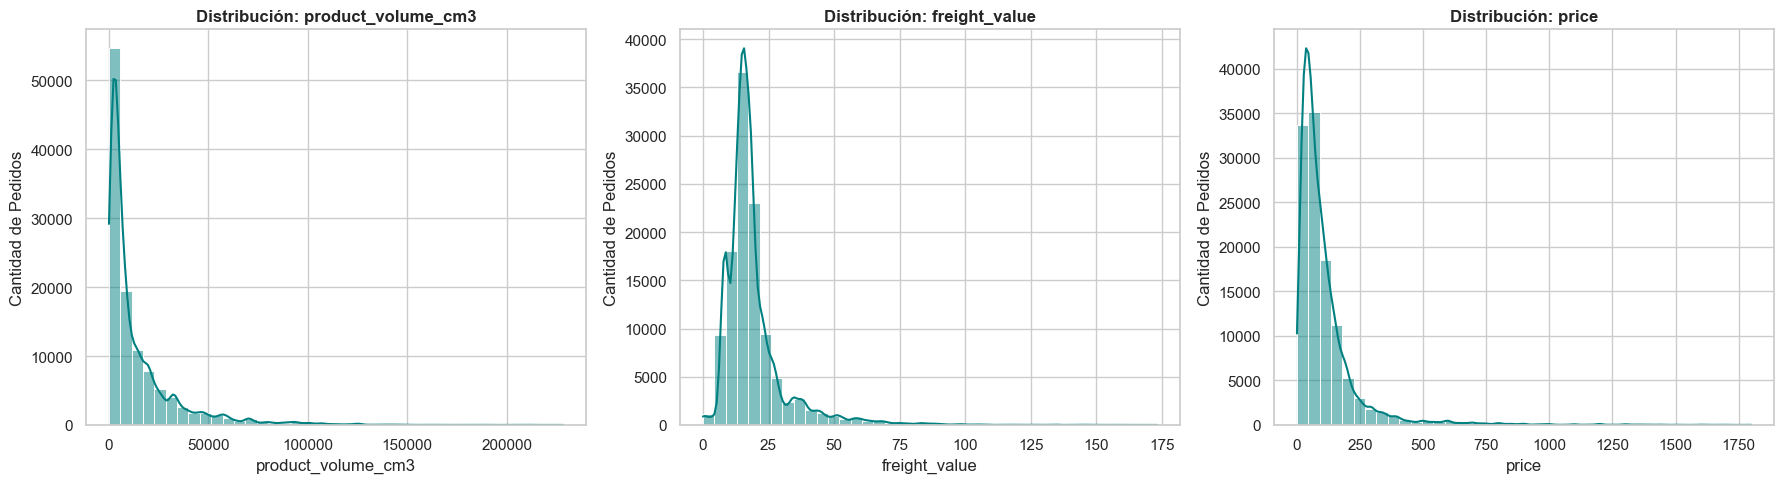

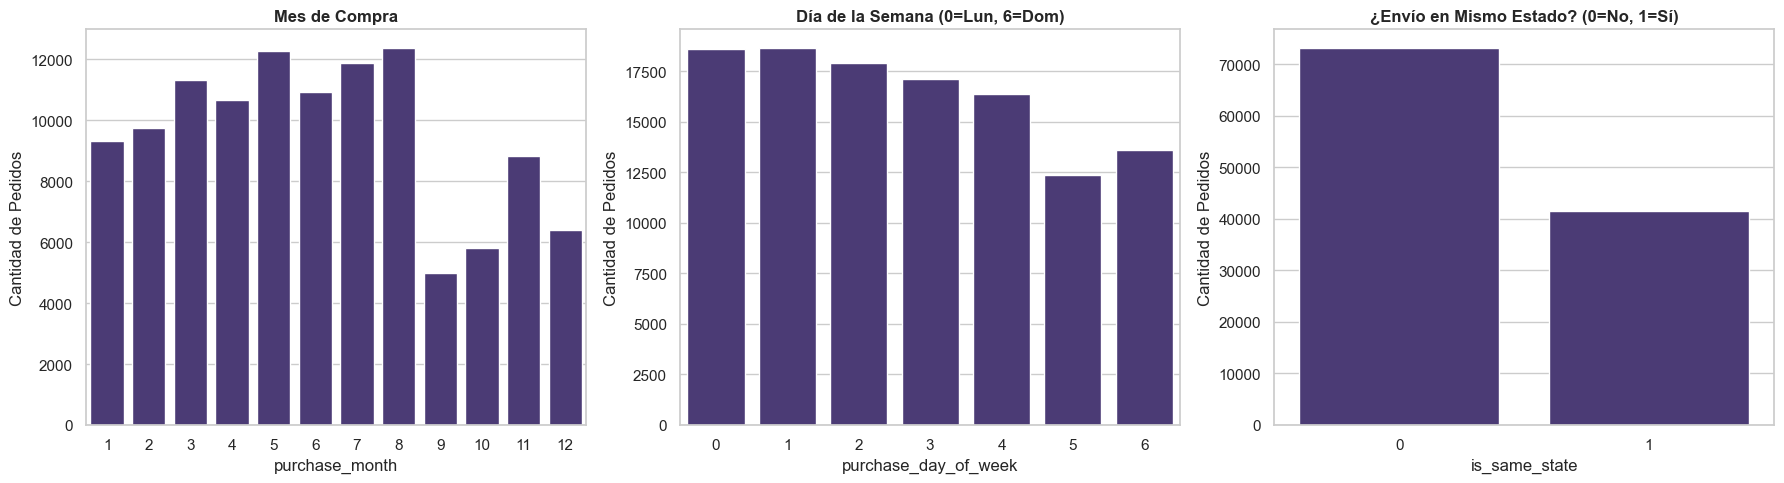

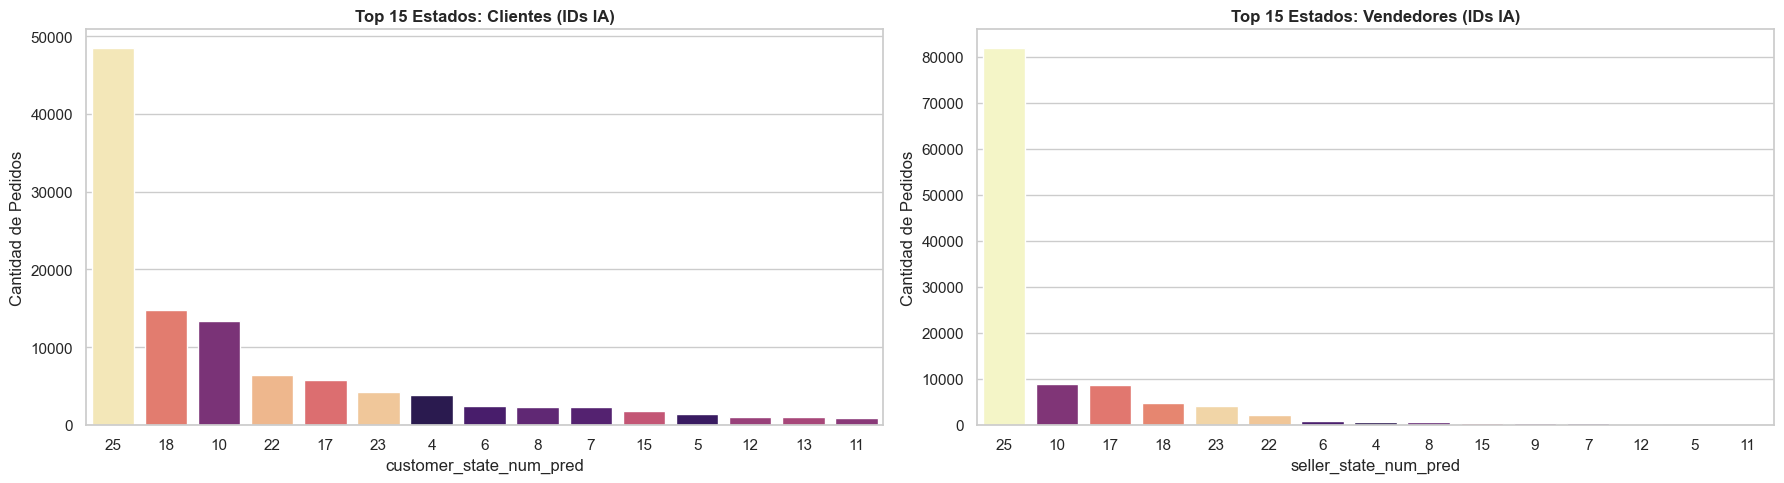

In [3]:
print("📊 DISTRIBUCIÓN DE VARIABLES PREDICTIVAS (FEATURES)\n")
print("-" * 50)

# Configuramos el estilo visual
sns.set_palette("viridis")

# --- 1. VARIABLES NUMÉRICAS CONTINUAS ---
# Volumen, Flete y Precio
num_features = ['product_volume_cm3', 'freight_value', 'price']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(num_features):
    # Usamos histogramas con KDE (Kernel Density Estimate) para ver la curva suave
    sns.histplot(df[col], bins=40, kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribución: {col}', fontweight='bold')
    axes[i].set_ylabel('Cantidad de Pedidos')

plt.tight_layout()
plt.show()

# --- 2. VARIABLES TEMPORALES Y OPERATIVAS ---
# Mes, Día de la semana y Si es el mismo estado
cat_features = ['purchase_month', 'purchase_day_of_week', 'is_same_state']
titulos_cat = ['Mes de Compra', 'Día de la Semana (0=Lun, 6=Dom)', '¿Envío en Mismo Estado? (0=No, 1=Sí)']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(cat_features):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(titulos_cat[i], fontweight='bold')
    axes[i].set_ylabel('Cantidad de Pedidos')

plt.tight_layout()
plt.show()

# --- 3. VARIABLES GEOGRÁFICAS (Top 15 Estados) ---
# Mostramos solo los 15 estados con más volumen para no saturar el gráfico
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# CORRECCIÓN AQUÍ: Se añade hue='customer_state_num_pred' y legend=False
sns.countplot(data=df, x='customer_state_num_pred', 
              hue='customer_state_num_pred',
              order=df['customer_state_num_pred'].value_counts().index[:15], 
              ax=axes[0], palette='magma', legend=False)
axes[0].set_title('Top 15 Estados: Clientes (IDs IA)', fontweight='bold')
axes[0].set_ylabel('Cantidad de Pedidos')

# CORRECCIÓN AQUÍ: Se añade hue='seller_state_num_pred' y legend=False
sns.countplot(data=df, x='seller_state_num_pred', 
              hue='seller_state_num_pred',
              order=df['seller_state_num_pred'].value_counts().index[:15], 
              ax=axes[1], palette='magma', legend=False)
axes[1].set_title('Top 15 Estados: Vendedores (IDs IA)', fontweight='bold')
axes[1].set_ylabel('Cantidad de Pedidos')

plt.tight_layout()
plt.show()

In [4]:
import os
import pandas as pd
import kagglehub

path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

# 1. Cargar el archivo de geolocalización usando el path de kagglehub
geo_file = os.path.join(path, 'olist_geolocation_dataset.csv')
print(f"Leyendo geolocalización desde: {geo_file}")
geo = pd.read_csv(geo_file)

# 2. Limpieza crítica: Un ZIP code puede tener muchas coordenadas (puntos GPS)
# Agrupamos por código postal para obtener un único punto central (lat/lng promedio)
geo_clean = geo.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean'
}).reset_index()

# 3. Preparar el merge para CLIENTES
# Nota: 'df' es tu dataset de modelado (el que cargaste de Filtered.pkl)
df = pd.merge(
    df, 
    geo_clean, 
    left_on='customer_zip_code_prefix', 
    right_on='geolocation_zip_code_prefix', 
    how='left'
)
df.rename(columns={'geolocation_lat': 'customer_lat', 'geolocation_lng': 'customer_lng'}, inplace=True)
df.drop('geolocation_zip_code_prefix', axis=1, inplace=True)

# 4. Preparar el merge para VENDEDORES
df = pd.merge(
    df, 
    geo_clean, 
    left_on='seller_zip_code_prefix', 
    right_on='geolocation_zip_code_prefix', 
    how='left'
)
df.rename(columns={'geolocation_lat': 'seller_lat', 'geolocation_lng': 'seller_lng'}, inplace=True)
df.drop('geolocation_zip_code_prefix', axis=1, inplace=True)

print(f"✅ Coordenadas integradas.")
print(f"Filas con coordenadas de cliente: {df['customer_lat'].notna().sum()}")
print(f"Filas con coordenadas de vendedor: {df['seller_lat'].notna().sum()}")

# Vista previa para verificar
display(df[['order_id', 'is_delayed', 'customer_lat', 'customer_lng', 'seller_lat', 'seller_lng']].head())

Leyendo geolocalización desde: /Users/sergio/.cache/kagglehub/datasets/olistbr/brazilian-ecommerce/versions/2/olist_geolocation_dataset.csv
✅ Coordenadas integradas.
Filas con coordenadas de cliente: 114264
Filas con coordenadas de vendedor: 114317


,order_id,is_delayed,customer_lat,customer_lng,seller_lat,seller_lng
0,e481f51cbdc54678b7cc49136f2d6af7,0,-23.576983,-46.587161,-23.680729,-46.444238
1,e481f51cbdc54678b7cc49136f2d6af7,0,-23.576983,-46.587161,-23.680729,-46.444238
2,e481f51cbdc54678b7cc49136f2d6af7,0,-23.576983,-46.587161,-23.680729,-46.444238
3,53cdb2fc8bc7dce0b6741e2150273451,0,-12.177924,-44.660711,-19.807681,-43.980427
4,47770eb9100c2d0c44946d9cf07ec65d,0,-16.745150,-48.514783,-21.363502,-48.229601


🗺️ Generando mapa de puntos individuales logísticos...


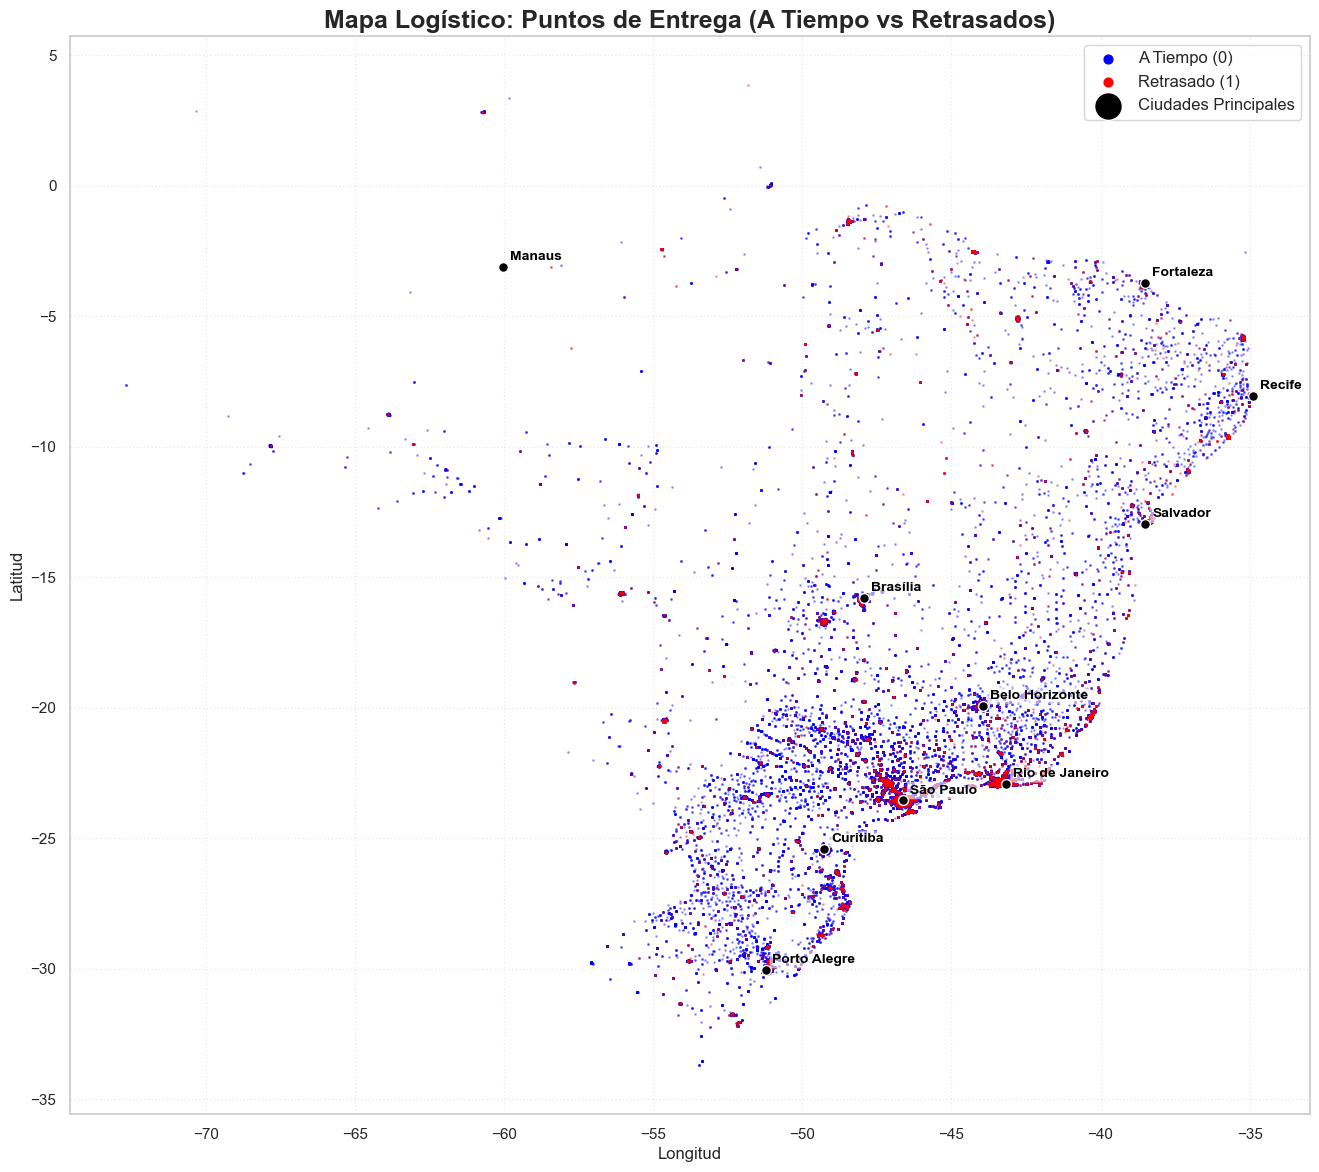

In [5]:
import matplotlib.pyplot as plt

print("🗺️ Generando mapa de puntos individuales logísticos...")

# 1. Filtrar anomalías geográficas (mantener solo coordenadas dentro de Brasil)
df_map = df[(df['customer_lat'] <= 5) & (df['customer_lat'] >= -35)]
df_map = df_map[(df_map['customer_lng'] <= -35) & (df_map['customer_lng'] >= -75)]

# 2. Separar los datos por clase
df_puntuales = df_map[df_map['is_delayed'] == 0]
df_retrasados = df_map[df_map['is_delayed'] == 1]

# 3. Diccionario de ciudades 
cities = {
    'São Paulo': (-23.55, -46.63), 'Rio de Janeiro': (-22.91, -43.17),
    'Brasília': (-15.78, -47.93), 'Salvador': (-12.97, -38.50),
    'Fortaleza': (-3.72, -38.52), 'Belo Horizonte': (-19.92, -43.94),
    'Curitiba': (-25.42, -49.27), 'Manaus': (-3.11, -60.02),
    'Recife': (-8.05, -34.88), 'Porto Alegre': (-30.03, -51.23)
}

plt.figure(figsize=(16, 14))

# --- CAPA 1: Pedidos Puntuales (Azul) ---
# alpha=1.0 hace que sea un color sólido, sin degradado. s=1 lo hace un punto fino.
plt.scatter(df_puntuales['customer_lng'], df_puntuales['customer_lat'], 
            alpha=0.3, s=1, c='blue', label='A Tiempo (0)', zorder=1)

# --- CAPA 2: Pedidos Retrasados (Rojo) ---
# alpha=1.0 para que el rojo sea puro y no se mezcle con el azul que tiene debajo
plt.scatter(df_retrasados['customer_lng'], df_retrasados['customer_lat'], 
            alpha=0.3, s=1, c='red', label='Retrasado (1)', zorder=2)

# --- CAPA 3: Ciudades Principales (Negro) ---
first_city = True
for city, coords in cities.items():
    lat, lng = coords
    lbl = 'Ciudades Principales' if first_city else ""
    
    # Punto negro con borde blanco
    plt.scatter(lng, lat, c='black', s=50, edgecolors='white', zorder=5, label=lbl)
    
    # Anotación con desplazamiento y caja blanca
    plt.annotate(city, 
                 xy=(lng, lat), 
                 xytext=(5, 5), 
                 textcoords='offset points',
                 fontsize=10,
                 fontweight='bold',
                 color='black',
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, ec='none'),
                 zorder=6)
    first_city = False

# --- ESTÉTICA Y LEYENDA CONSISTENTE ---
plt.title('Mapa Logístico: Puntos de Entrega (A Tiempo vs Retrasados)', fontsize=18, fontweight='bold')
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.4)

# Creamos la leyenda
leg = plt.legend(fontsize=12, loc='upper right', frameon=True)

# TRUCO DE CONSISTENCIA PARA LA LEYENDA
for i, lh in enumerate(leg.legend_handles): 
    lh.set_alpha(1) # Aseguramos opacidad total también en la leyenda
    
    if i < 2:
        # Agrandamos los puntos azul y rojo solo en la leyenda
        lh.set_sizes([40])  
    else:
        # Hacemos el punto negro de la ciudad un poco más pequeño en la leyenda
        lh.set_sizes([400])  

plt.show()